In [69]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from datetime import datetime

In [70]:
# Load the high-pay data
high_pay_data = pd.read_csv('./Data/cleaned_high_pay_data.csv')

# Load the shapefile into a GeoDataFrame
shapefile_path = './us_state/us_state.shp'
us_states = gpd.read_file(shapefile_path)


In [71]:
us_states.columns

Index(['REGION', 'DIVISION', 'STATEFP', 'STATENS', 'GEOID', 'GEOIDFQ',
       'STUSPS', 'NAME', 'LSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER',
       'INTPTLAT', 'INTPTLON', 'geometry'],
      dtype='object')

** Question:1** 

In [72]:
# Create a copy from the  original DataFrame
education_level_data = high_pay_data[['State Abbreviation', 'Education Level']]

In [73]:
# Get the dominant education level for each state
dominant_education = education_level_data.value_counts().reset_index(name='Count')

In [ ]:
# Get the top education level for each state
# Assuming 'dominant_education' has a column 'Education Level' for the education level and 'State Abbreviation' for states
# dominant_education = dominant_education.loc[dominant_education.groupby('State Abbreviation')['Education Level'].idxmax()]


In [25]:
#check data structure 
dominant_education.head()

,State Abbreviation,Education Level,Count
0,CA,Bachelor's degree,1389
1,CA,Master's degree,808
2,NY,Bachelor's degree,544
3,NY,Master's degree,360
4,TX,Bachelor's degree,349


In [74]:
# # Merge the dominant education level with the geographic data
geo_dominant_education = us_states.merge(dominant_education, left_on='STUSPS' ,right_on='State Abbreviation')



In [63]:
geo_dominant_education.head(2)

,REGION,DIVISION,STATEFP,STATENS,GEOID,GEOIDFQ,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,State Abbreviation,Education Level,Count
0,3,5,54,01779805,54,0400000US54,WV,West Virginia,00,G4000,A,62266513826,488918898,+38.6472854,-080.6183274,"POLYGON ((-77.75438 39.33346, -77.75422 39.333...",WV,Master's degree,10
1,3,5,54,01779805,54,0400000US54,WV,West Virginia,00,G4000,A,62266513826,488918898,+38.6472854,-080.6183274,"POLYGON ((-77.75438 39.33346, -77.75422 39.333...",WV,Bachelor's degree,4


In [75]:
# Ensure `geo_dominant_education` is a GeoDataFrame for spatial plotting
geo_dominant_education = gpd.GeoDataFrame(geo_dominant_education, geometry='geometry')

In [76]:
geo_dominant_education=geo_dominant_education.loc[~geo_dominant_education['STUSPS'].isin(['AK', 'HI'])]

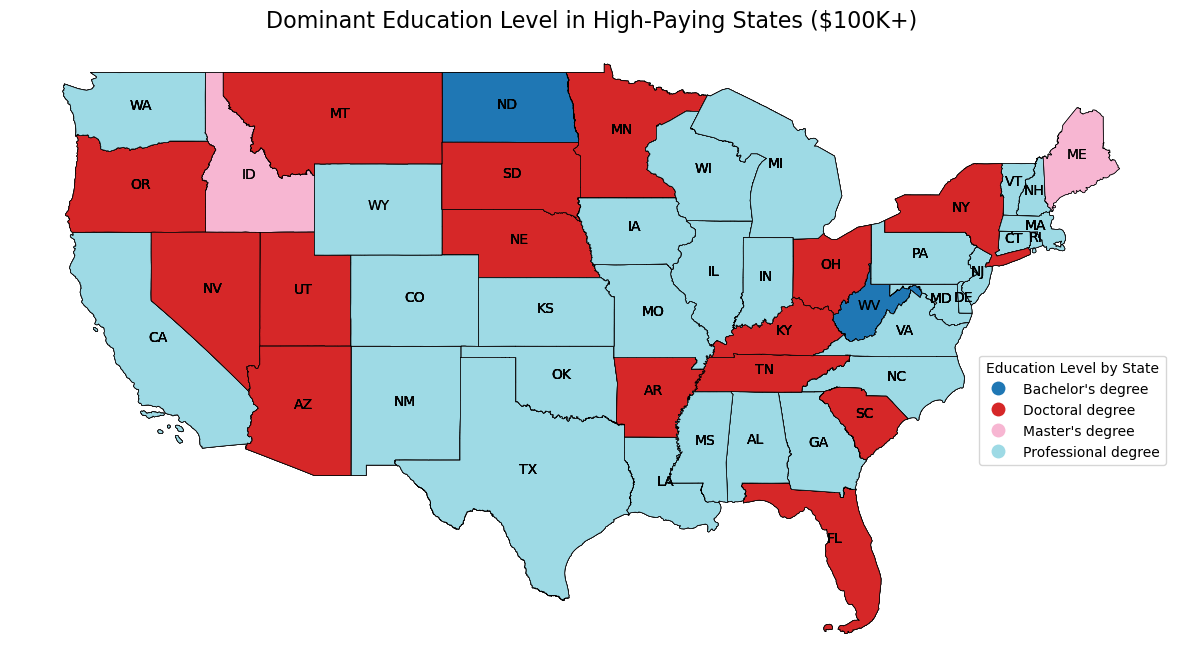

In [77]:
# Set up the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the map with the dominant education level for each state
geo_dominant_education.plot(
    column='Education Level',  # This is the column used for coloring
    ax=ax,
    cmap='tab20',  # A good color map for categorical data
    legend=True,  # Show the legend
    linewidth=0.5,
    edgecolor='black',  # Outline states in black
    legend_kwds={'title': "Education Level by State"}  # Corrected legend title
)

# Add state abbreviations to the map
for idx, row in geo_dominant_education.iterrows():
    centroid = row['geometry'].centroid  # Get the centroid of each state
    ax.text(centroid.x, centroid.y, row['STUSPS'], fontsize=10, ha='center', color='black')

# Title for the map
plt.title('Dominant Education Level in High-Paying States ($100K+)', fontsize=16)

# Turn off axis for cleaner visualization
plt.axis('off')

# Move the legend to the best position
ax.get_legend().set_bbox_to_anchor((1, 0.5))  # Move the legend to the right side

# Save the plot with a dynamic filename
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"Images/dominant_education_by_state_{timestamp}.png"
plt.savefig(filename, bbox_inches='tight', dpi=300)

# Show the plot
plt.show()


In [84]:
us_states.columns

Index(['REGION', 'DIVISION', 'STATEFP', 'STATENS', 'GEOID', 'GEOIDFQ',
       'STUSPS', 'NAME', 'LSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER',
       'INTPTLAT', 'INTPTLON', 'geometry'],
      dtype='object')

2. **Question:** Which states have the highest concentration of high-paying jobs ($100K+ annual income)?

In [ ]:
# Calculate high-paying job totals and total jobs by state
job_data = (
    high_pay_data.groupby('State Abbreviation')
    .agg(High_Paying_Jobs=('Annual Income', 'size'), Total_Jobs=('Employment', 'size'))
    .reset_index()
)
#add the location tothe data frame
job_data['Location Quotient']=high_pay_data['Location Quotient']

# Merge with `us_states` GeoDataFrame for visualization or mapping purposes
job_data_geo = pd.merge(us_states, job_data, left_on='STUSPS', right_on='State Abbreviation', how='left')


In [43]:
# Keep only necessary columns for plotting
plot_data = job_data_geo[['geometry', 'STUSPS', 'High_Paying_Jobs', 'Location Quotient']]

In [44]:
# Convert the merged DataFrame into a GeoDataFrame with spatial geometry for plotting
plot_data = gpd.GeoDataFrame(plot_data, geometry=plot_data.geometry)

# Exclude Alaska (AK) and Hawaii (HI) from the data for easier mapping
plot_data = plot_data.loc[~plot_data['STUSPS'].isin(['AK', 'HI'])]

In [79]:
import matplotlib.pyplot as plt
from datetime import datetime

def StatesPlot(df, column_to_plot, cmap='viridis', label_color='black', label_size=6,
               title='United States Map', filename='us_map.png', min_value=None, max_value=None,
               edge_color='black', edge_linewidth=0.5):
    """
    Plots a US map based on state data and a specified column (e.g., income or education levels).

    Parameters:
    df (GeoDataFrame): Geodataframe containing the state geometries and data to plot.
    column_to_plot (str): Column name representing the data to be visualized (e.g., income levels, education levels).
    cmap (str): Color map to use for visualization.
    label_color (str): Color of the state labels.
    label_size (int): Font size of the state labels.
    title (str): Title of the plot.
    filename (str): Name of the file to save the plot.
    min_value (float, optional): Minimum value to be used for color scaling (optional).
    max_value (float, optional): Maximum value to be used for color scaling (optional).
    edge_color (str): Color of the state borders.
    edge_linewidth (float): Width of the state borders.

    Returns:
    None
    """
    # Ensure the column exists in the dataframe
    if column_to_plot not in df.columns:
        print(f"Error: '{column_to_plot}' column not found in the DataFrame.")
        return
    
    # Handle missing values in the column (replace NaN with a default value, or remove rows)
    df = df.dropna(how='any')  # Drop rows with missing data in the column to plot
    
    # If no specific min/max is provided, set them based on the column's values
    if min_value is None:
        min_value = df[column_to_plot].min()
    if max_value is None:
        max_value = df[column_to_plot].max()

    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=(15, 10), dpi=300)
    ax.set_axis_off()  # Turn off the axis to focus on the map

    # Plot the state geometries using the selected column
    df.plot(column=column_to_plot, ax=ax, alpha=0.7, cmap=cmap, legend=False, 
            linewidth=edge_linewidth, edgecolor=edge_color,  # Added edgecolor and linewidth
            vmin=min_value, vmax=max_value)

    # Add the color bar representing the data values (e.g., income, education level)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min_value, vmax=max_value))
    sm.set_array([])  # Empty array to avoid issues with ScalarMappable
    fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04, aspect=10)

    # Add the title
    plt.title(title, fontsize=16)

    # Add state names (labels) to the map
    for idx, row in df.iterrows():
        try:
            centroid = row['geometry'].centroid
            ax.text(centroid.x, centroid.y, row['STUSPS'], fontsize=label_size, ha='center', color=label_color)
        except Exception as e:
            print(f"Error labeling state {row['STUSPS']}: {e}")

    # Save the figure as a PNG file for the report
    # Append a timestamp to the filename to avoid overwriting
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    updated_filename = f"Images/{filename.split('.')[0]}_{timestamp}.png"
    plt.savefig(updated_filename, bbox_inches='tight', dpi=300)

    print(f"Map saved to {updated_filename}")

    # Show the plot
    plt.show()

Map saved to Images/High-Paying Jobs Distribution_20241129_213552.png


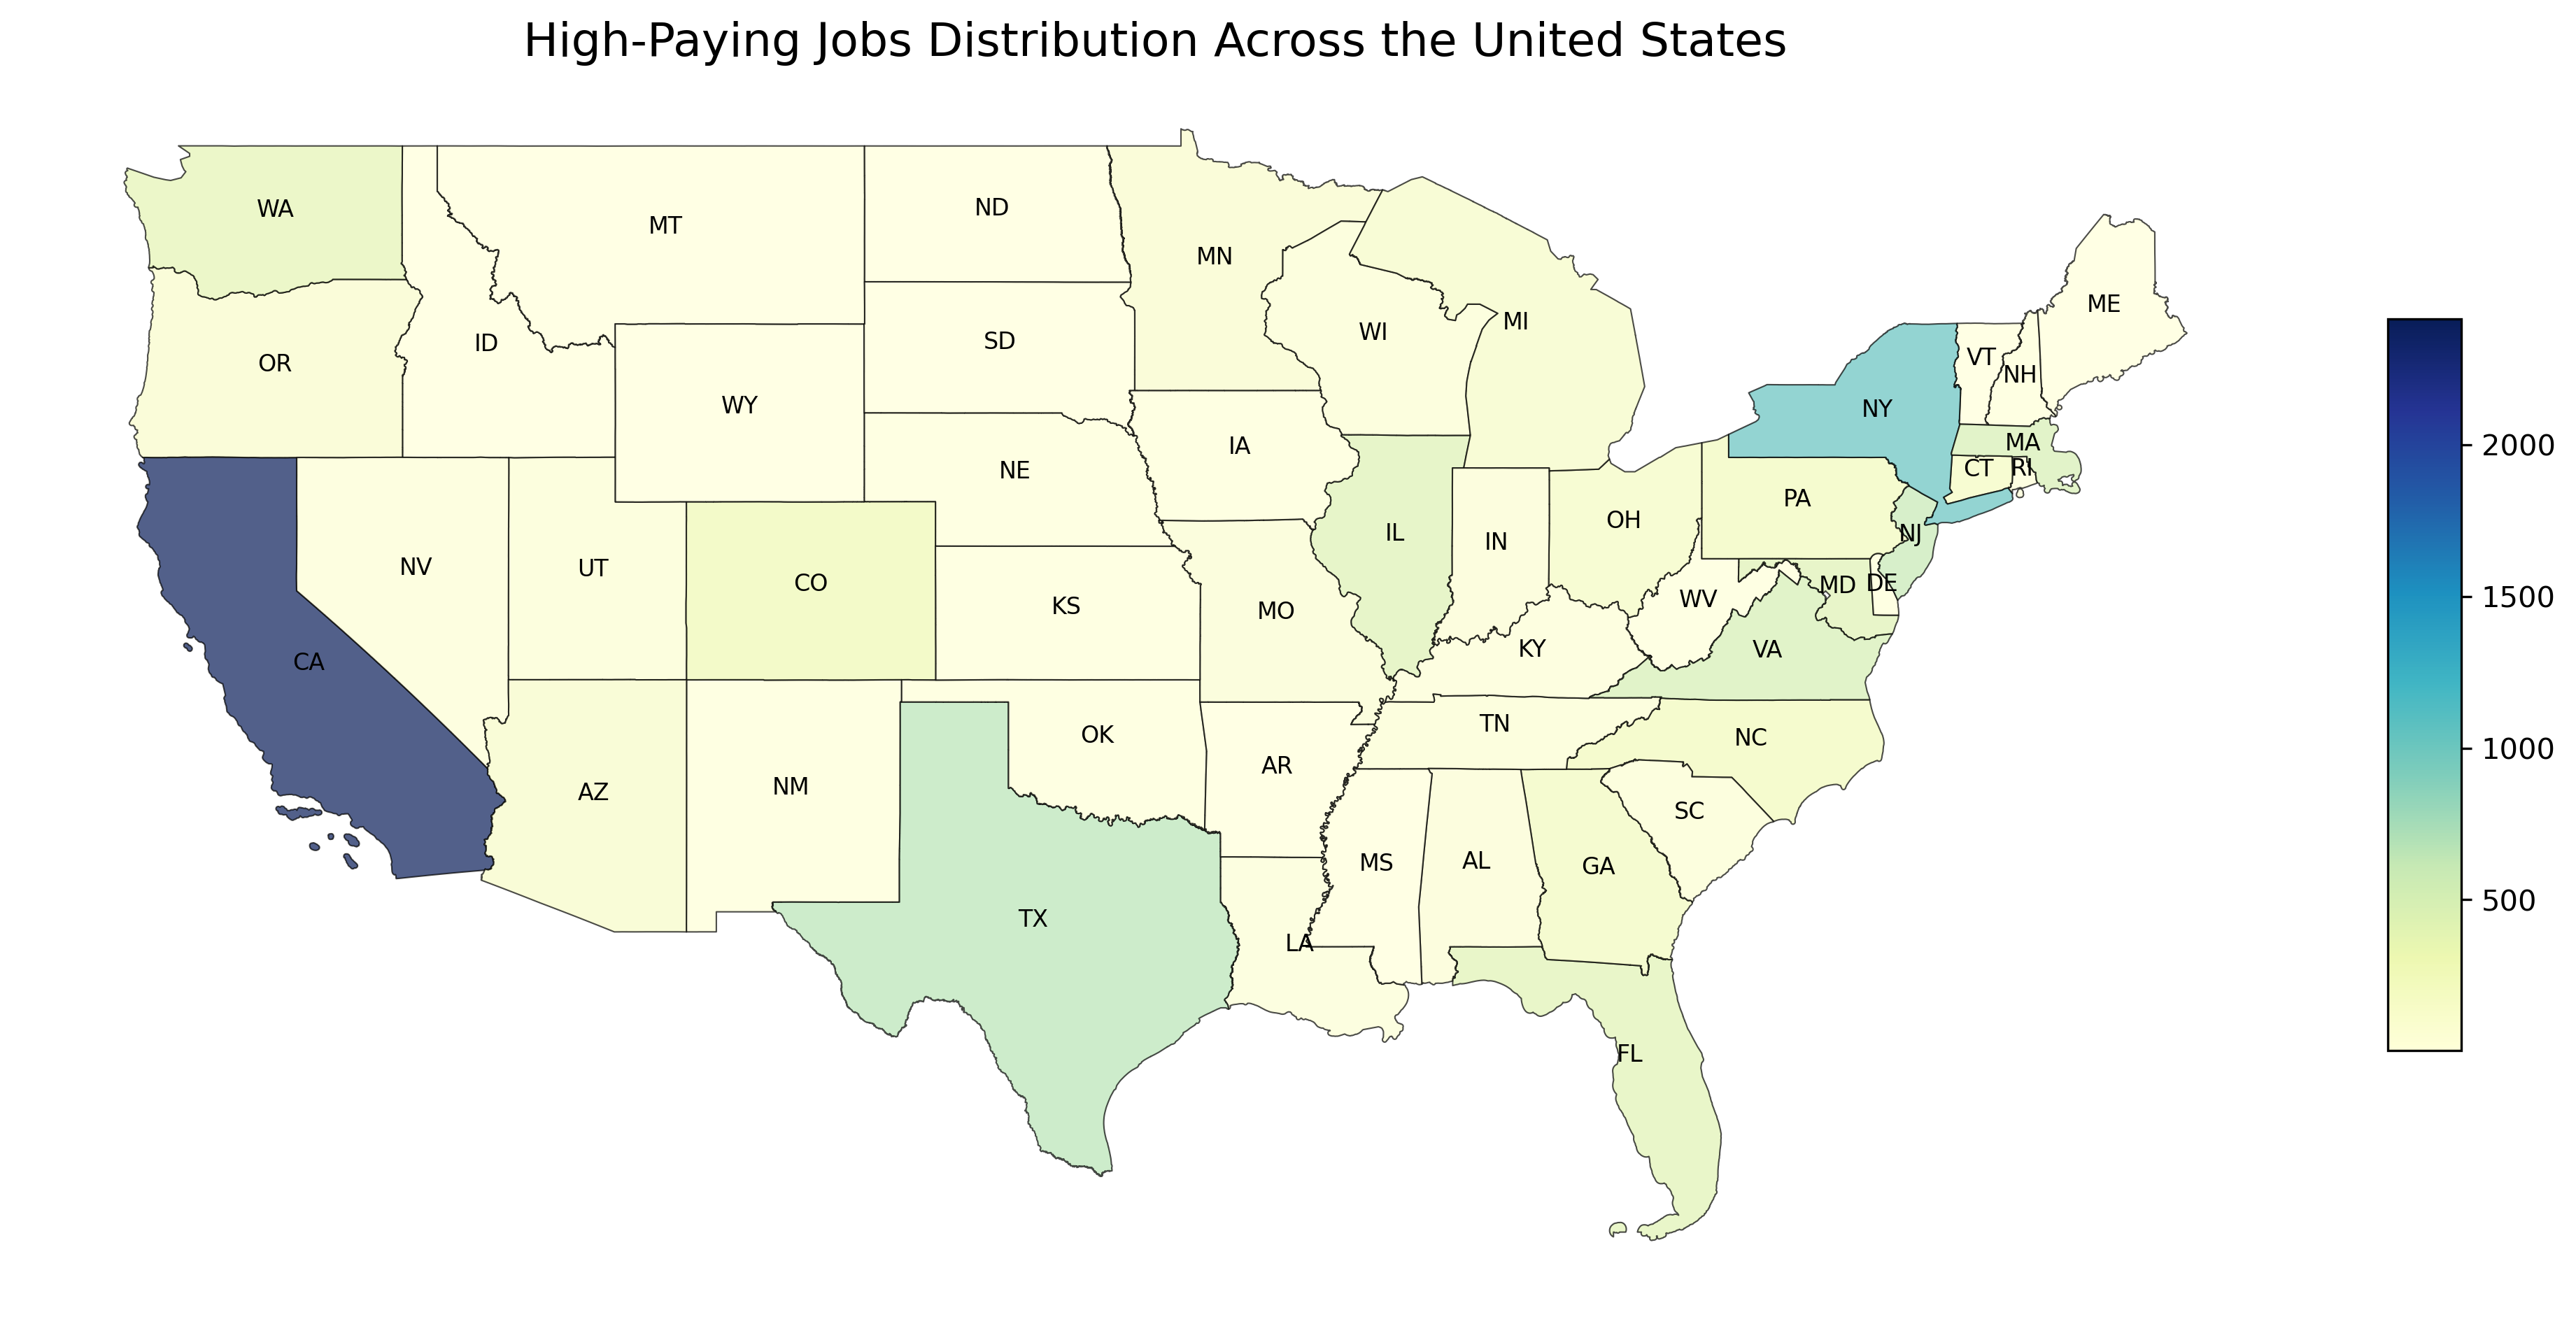

In [66]:
StatesPlot(
    df=plot_data,
    column_to_plot='High_Paying_Jobs',
    cmap='YlGnBu',
    label_color='black',
    label_size=8,
    title='High-Paying Jobs Distribution Across the United States',
    filename='High-Paying Jobs Distribution.png',
    edge_color='black'
)

In [78]:
# Calculate the average annual income by state
A_income_state = (high_pay_data.groupby(['State Abbreviation'])['Annual Income']
                  .mean()
                  .reset_index()
                  .round(2))
                
# Merge the calculated annual income data with state geometries
# 'left_on' is the 'State Abbreviation' from A_income_state, and 'right_on' is the 'STUSPS' from the US states GeoDataFrame
geo_income_data = A_income_state.merge(us_states, left_on='State Abbreviation', right_on='STUSPS')

# Convert the merged DataFrame into a GeoDataFrame with spatial geometry for plotting
geo_income_data = gpd.GeoDataFrame(geo_income_data, geometry=geo_income_data.geometry)

# Exclude Alaska (AK) and Hawaii (HI) from the data for easier mapping
geo_income_data = geo_income_data.loc[~geo_income_data['STUSPS'].isin(['AK', 'HI'])]


Map saved to Images/Highest_Income_state_20241129_215548.png


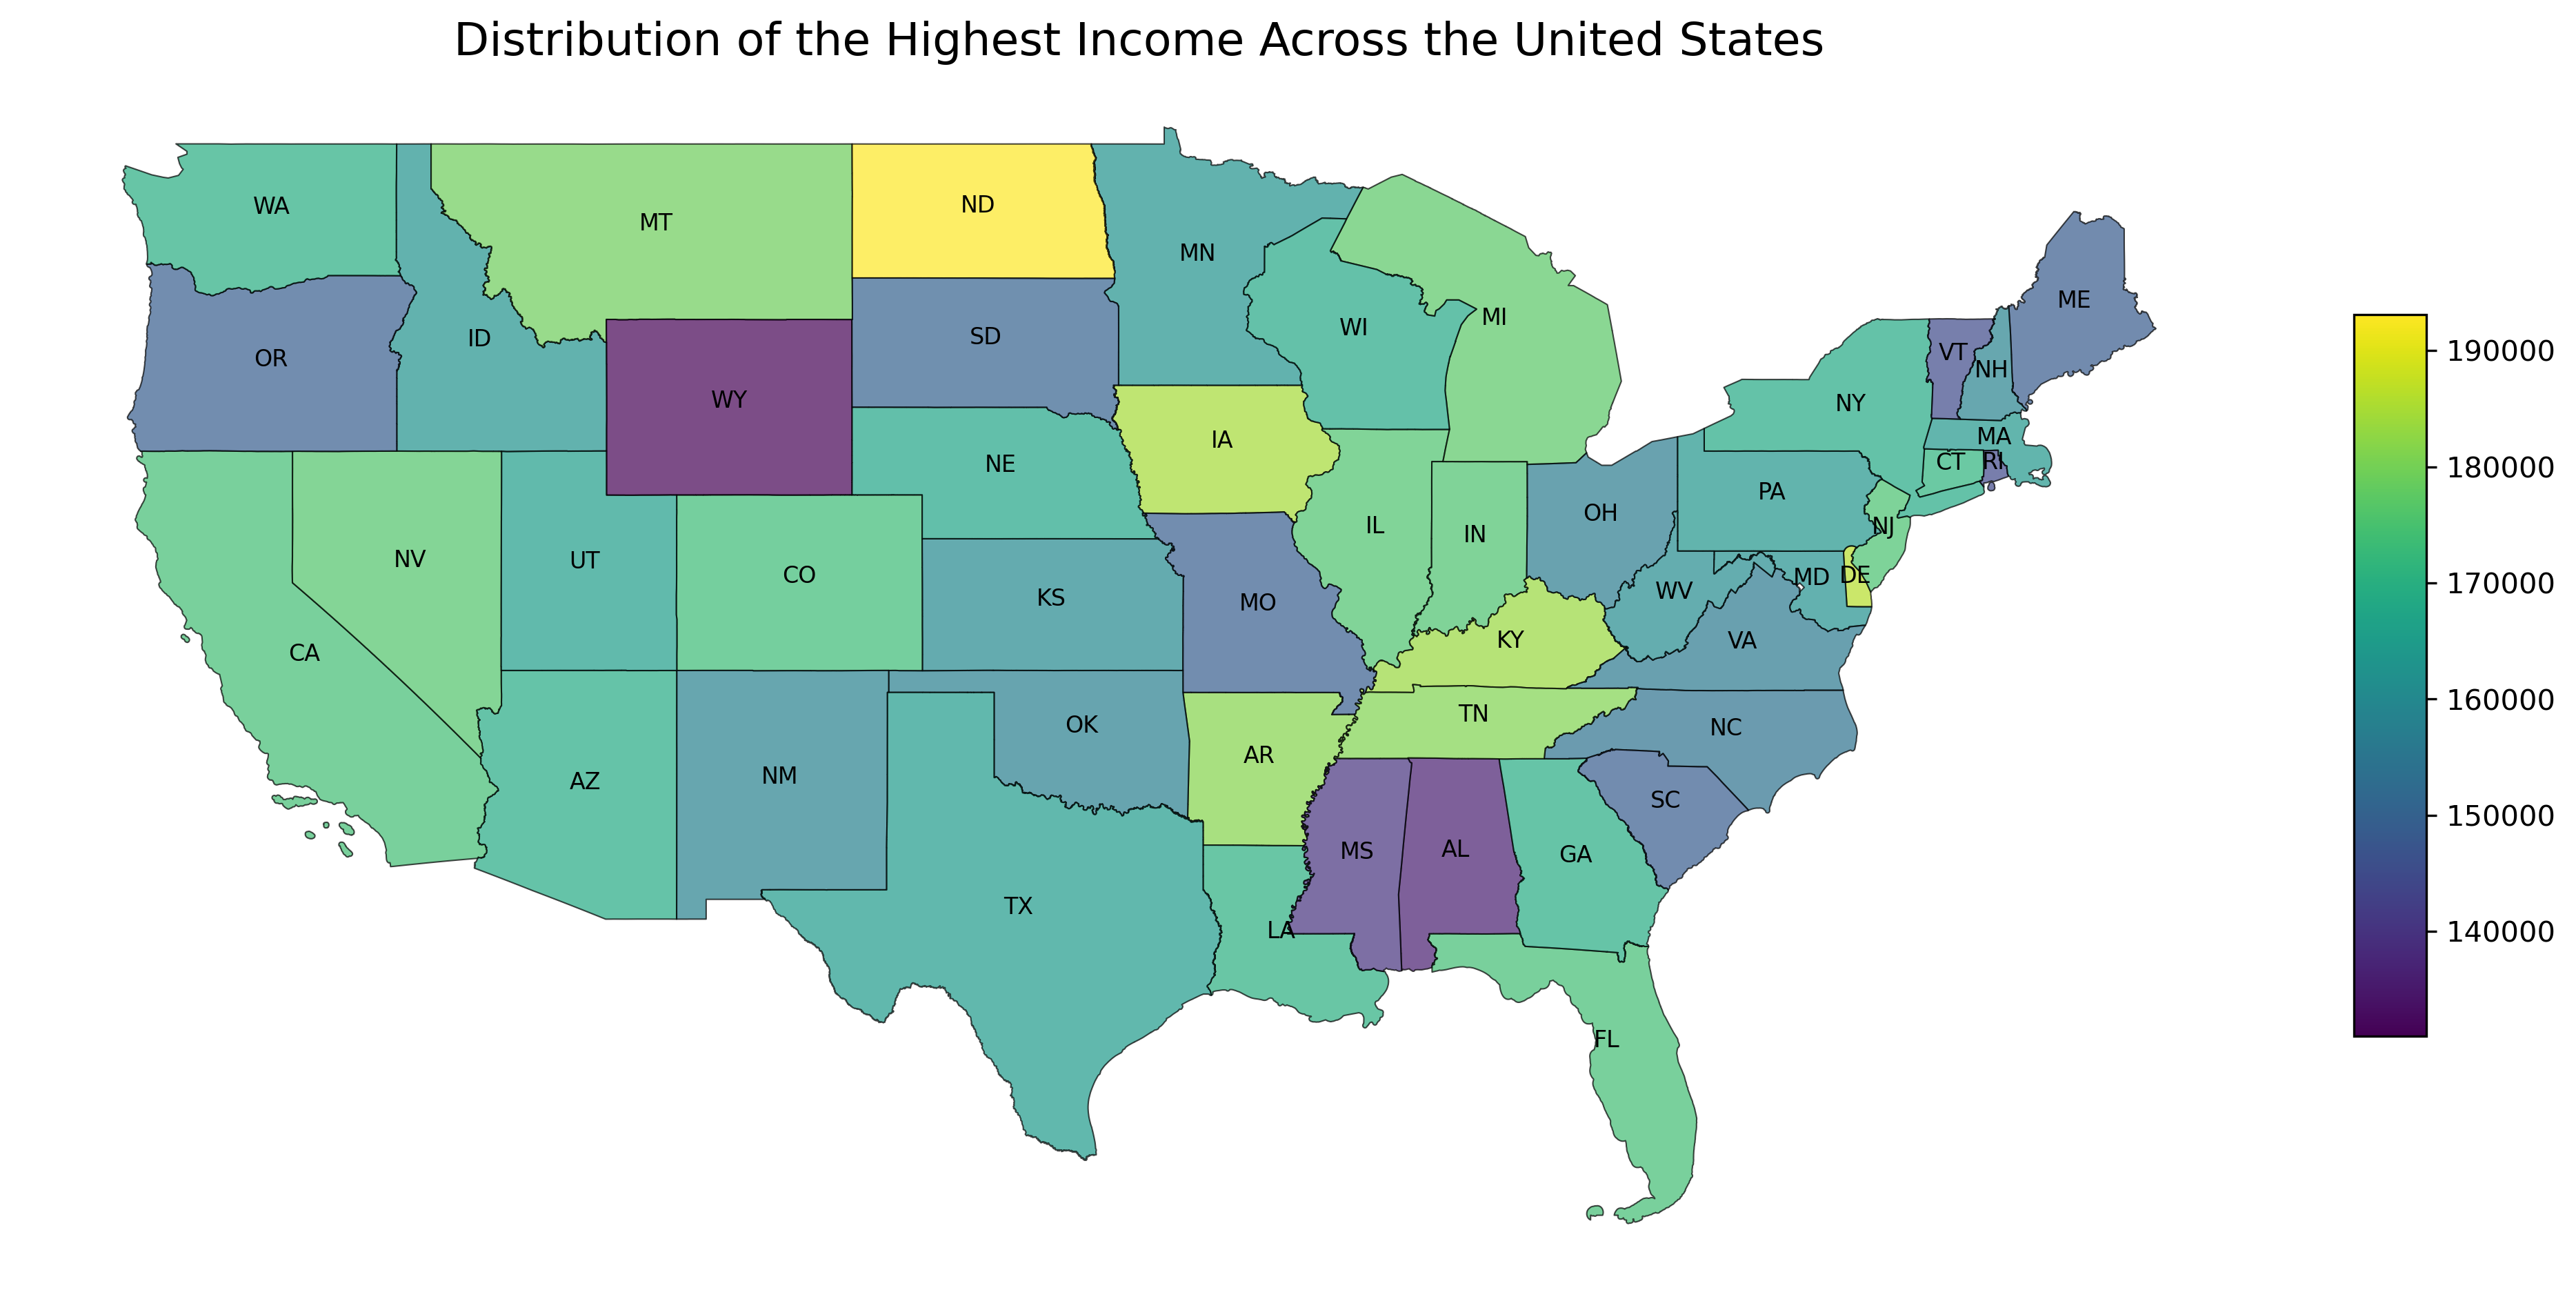

In [ ]:
StatesPlot(
    df=geo_income_data,
    column_to_plot='Annual Income',
    cmap='viridis',
    label_color='black',
    label_size=8,
    title='Distribution of the Highest Income Across the United States',  # Updated title
    filename='Average_Highest_Income_state.png',  
    edge_color='black'
)

In [81]:
# Step 1: Filter and Aggregate the Data
# Group by State and Gender to get counts
gender_counts = high_pay_data.groupby(['State', 'Gender']).size().unstack(fill_value=0)

# Step 2: Calculate Percentages
gender_counts['Total'] = gender_counts.sum(axis=1)
gender_counts['Male_Percentage'] = (gender_counts['Male'] / gender_counts['Total']) * 100
gender_counts['Female_Percentage'] = (gender_counts['Female'] / gender_counts['Total']) * 100

# Reset index to have State as a column
gender_counts.reset_index(inplace=True)

# Step 3: Merge with Geographical Data
# Ensure the state names match between the two datasets
merged_data = us_states.merge(gender_counts, left_on='NAME', right_on='State', how='left')

# Now merged_data contains the necessary information for mapping

In [83]:
merged_data.columns

Index(['REGION', 'DIVISION', 'STATEFP', 'STATENS', 'GEOID', 'GEOIDFQ',
       'STUSPS', 'NAME', 'LSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER',
       'INTPTLAT', 'INTPTLON', 'geometry', 'State', 'Female', 'Male', 'Total',
       'Male_Percentage', 'Female_Percentage'],
      dtype='object')

In [ ]:
goe_geneder_df=merged_data[['STUSPS','geometry','Male_Percentage','Female_Percentage']]
#exclude ak and hi
goe_geneder_df = goe_geneder_df.loc[~goe_geneder_df['STUSPS'].isin(['AK', 'HI'])]

Map saved to Images/Male_Percentage_state_20241129_220519.png


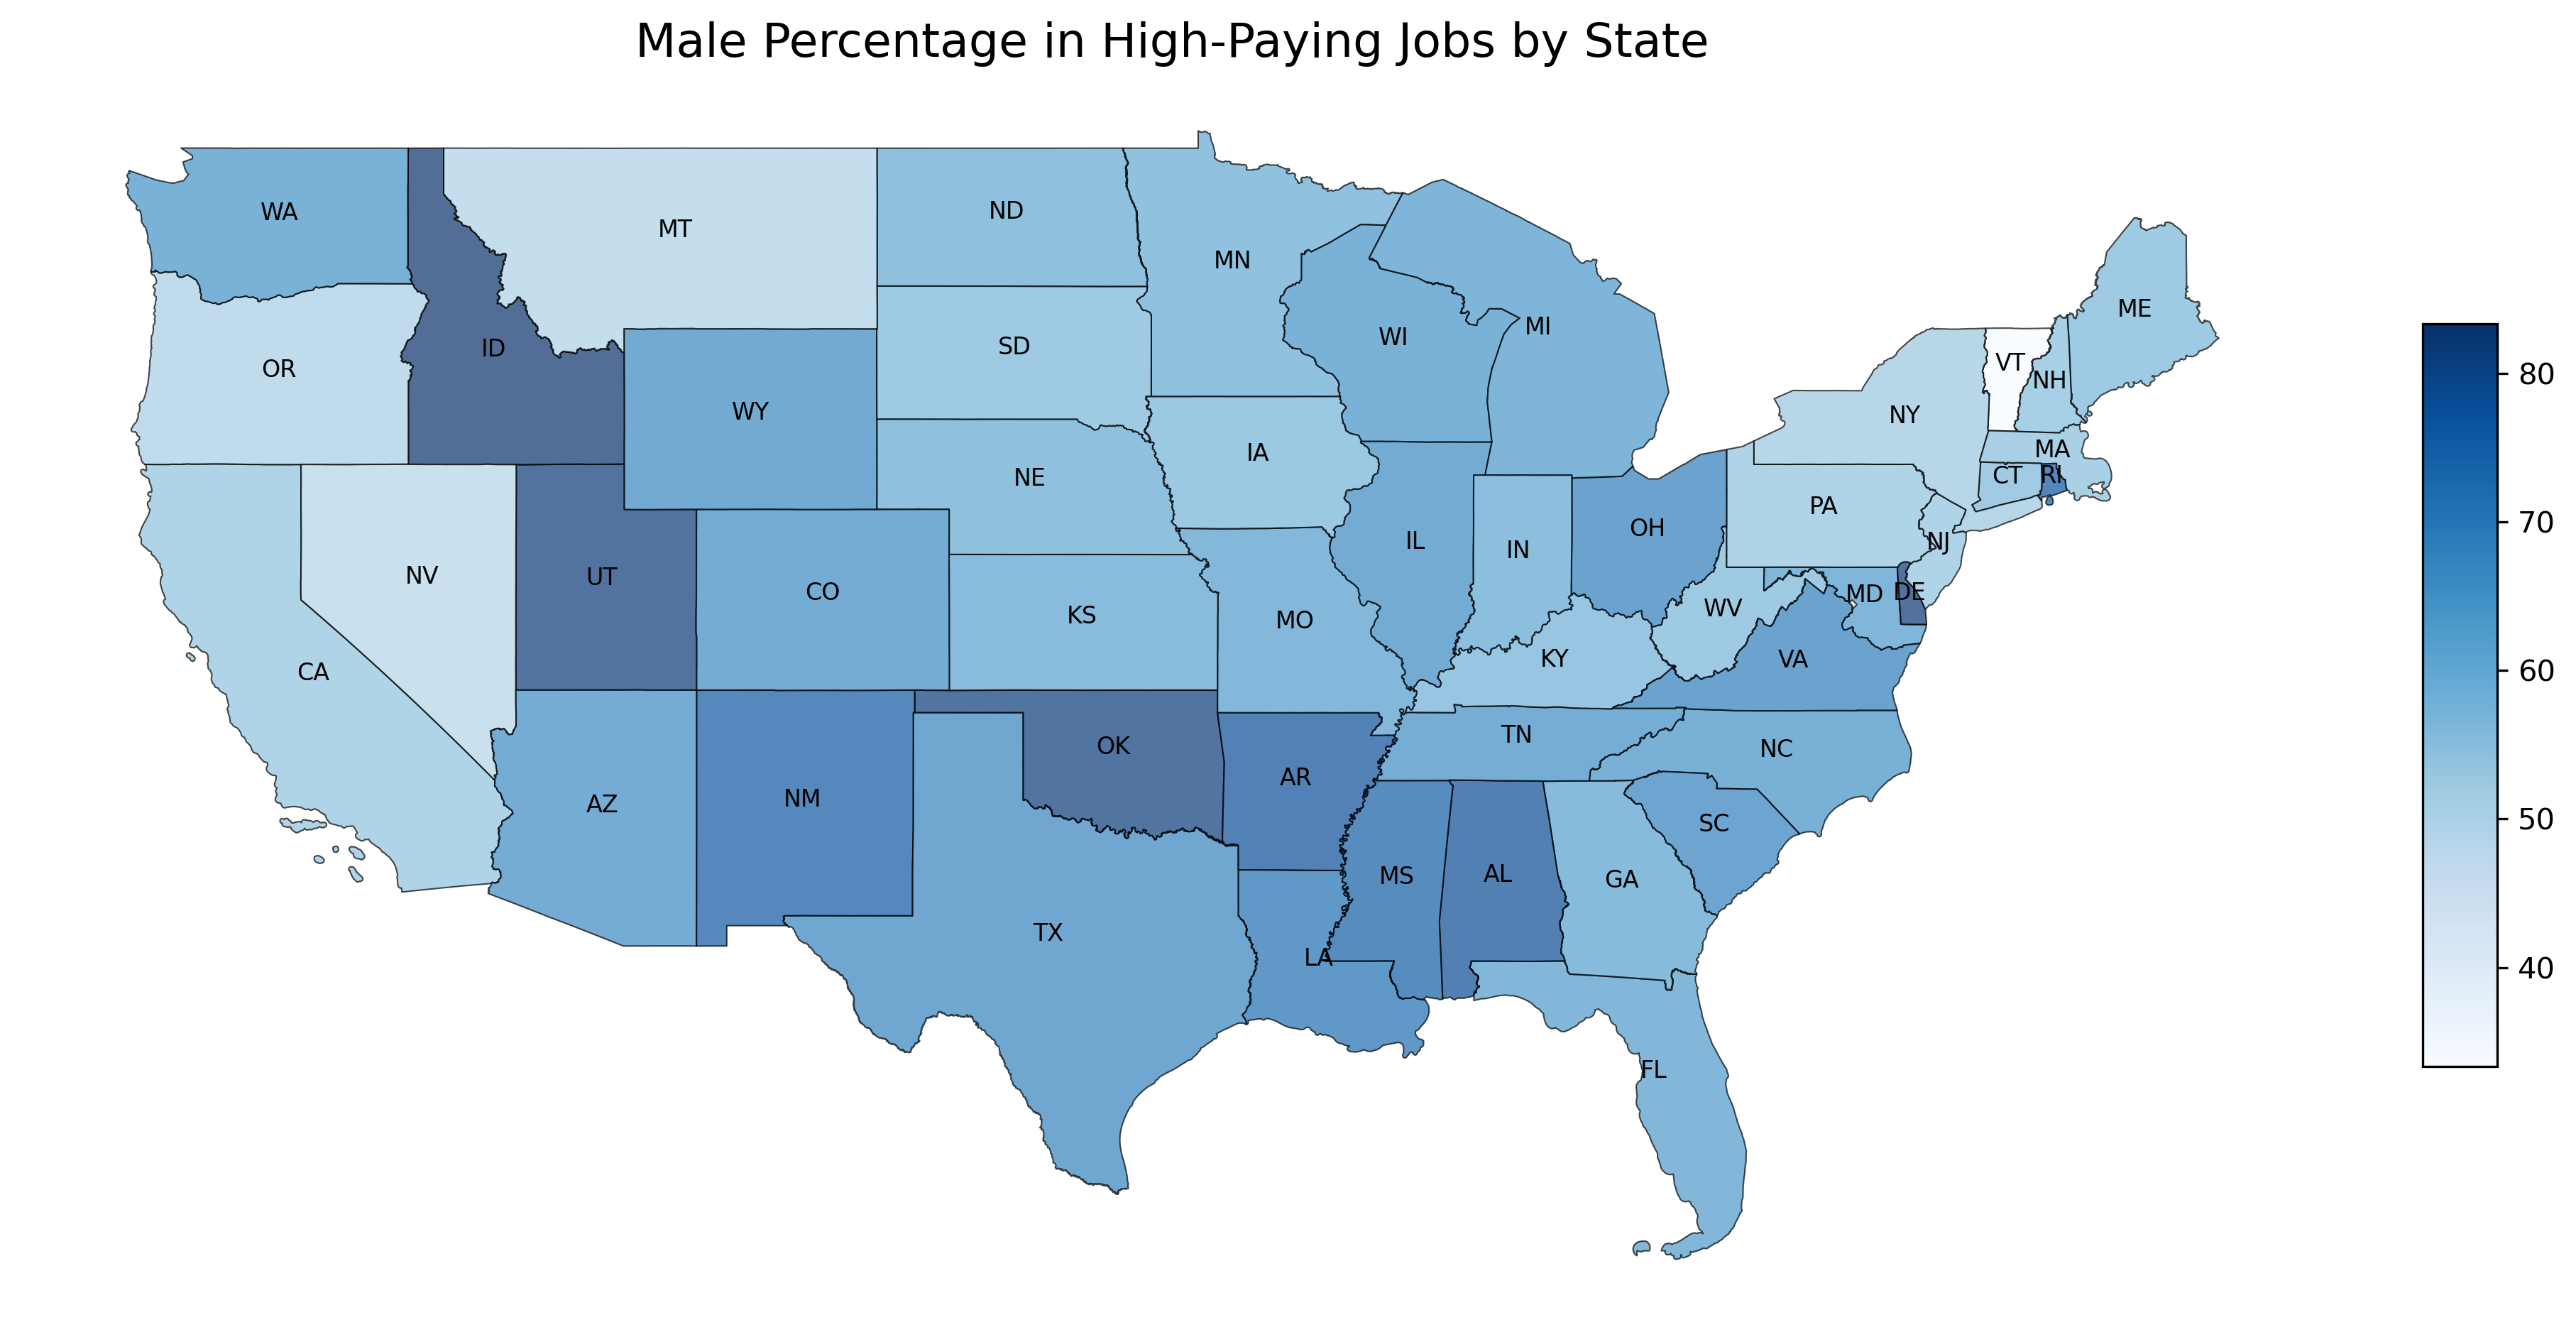

In [ ]:

StatesPlot(
    df=goe_geneder_df,
    column_to_plot='Male_Percentage',
    cmap='Blues',
    label_color='black',
    label_size=8,
    title='Male Percentage in High-Paying Jobs by State',  # Updated title
    filename='Male_Percentage_state.png',  
    edge_color='black'
)


Map saved to Images/Female_Percentage_state_20241129_220839.png


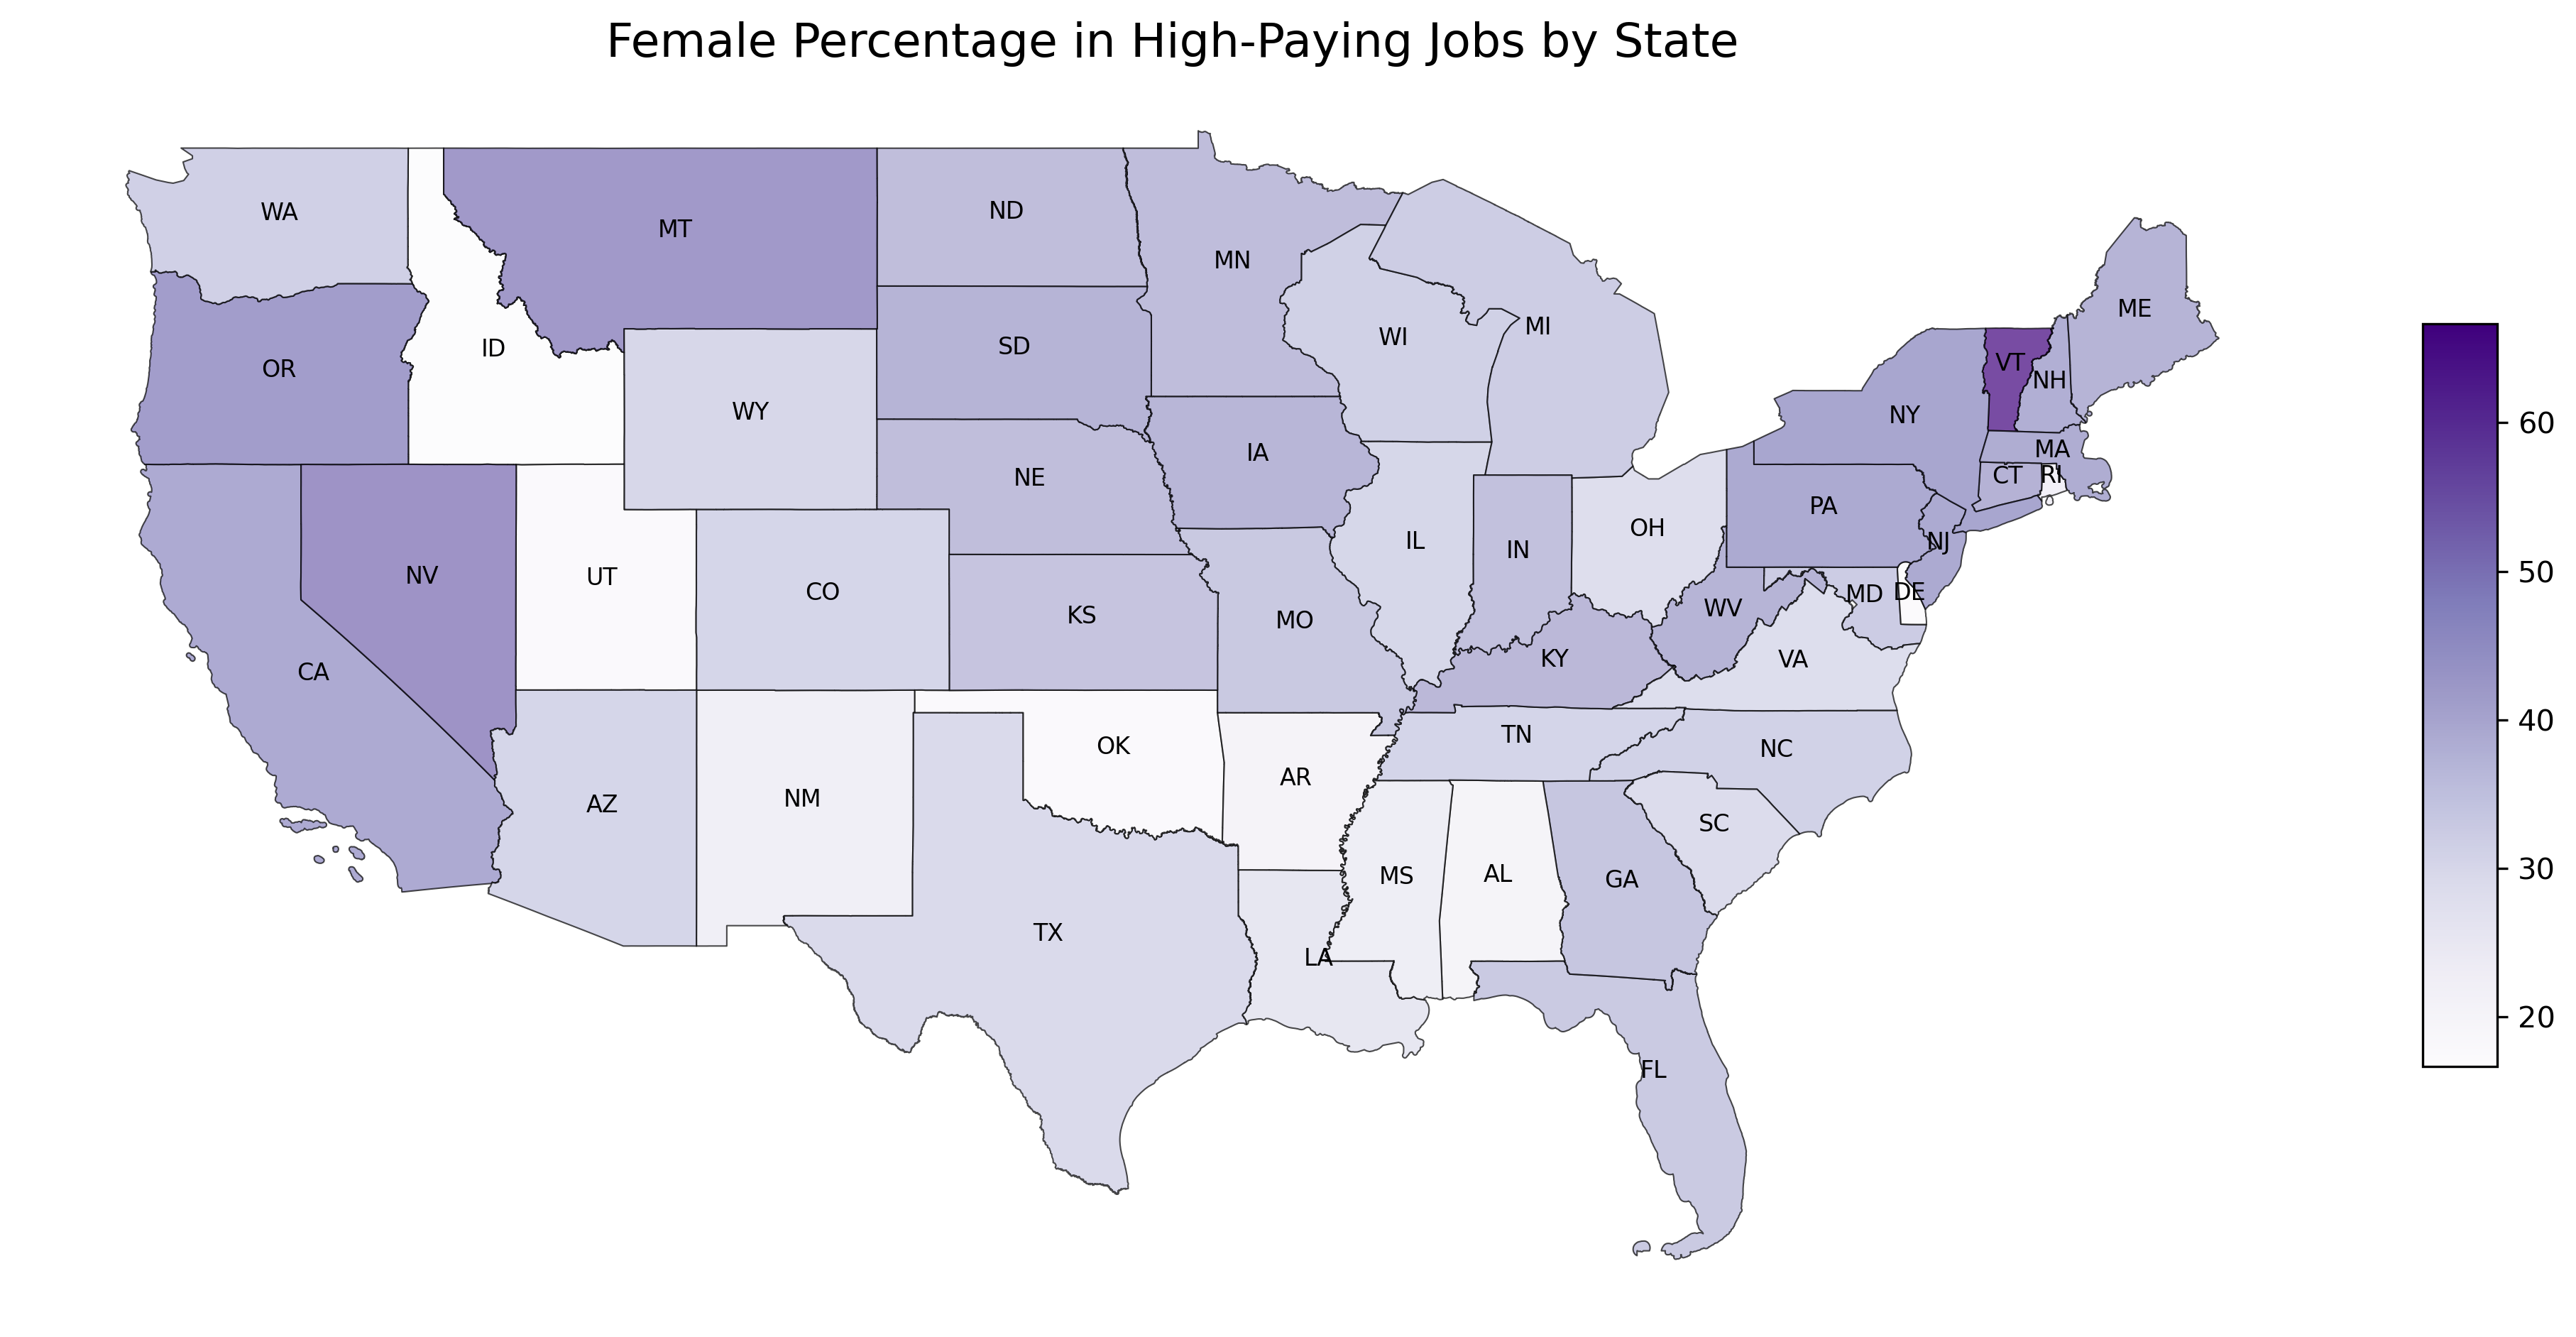

In [88]:
StatesPlot(
    df=goe_geneder_df,
    column_to_plot='Female_Percentage',
    cmap='Purples',
    label_color='black',
    label_size=8,
    title='Female Percentage in High-Paying Jobs by State',  # Updated title
    filename='Female_Percentage_state.png',  
    edge_color='black'
)
